In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nx.__version__

'3.2.1'

In [3]:
INPUT_FILE_PATH = '/Users/alexander/Downloads/American_Gut.graphml' #main graph ML input
OUTPUT_PATH = '/Users/alexander/American_Gut'                       #output folder
OUTPUT_NAME = 'American_Gut_w'                                      #output file name 

In [9]:
#sigmoid parameters
K = 20
C = 0.75

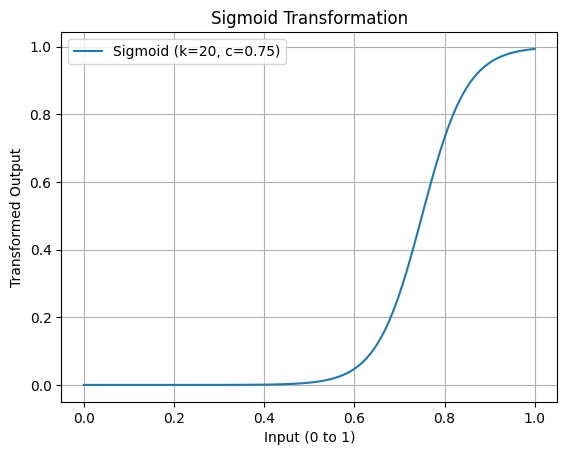

In [10]:
# Define sigmoid function
def custom_sigmoid(x, k=20, c=0.5):
    return 1 / (1 + np.exp(-k * (x - c)))

# Input values from 0 to 1
x = np.linspace(0, 1, 100)

# Apply sigmoid
y = custom_sigmoid(x, k=K, c=C)

# Plot the transformation
plt.plot(x, y, label=f'Sigmoid (k={K}, c={C})')
plt.title('Sigmoid Transformation')
plt.xlabel('Input (0 to 1)')
plt.ylabel('Transformed Output')
plt.legend()
plt.grid()
plt.show()

In [4]:
G = nx.read_graphml(INPUT_FILE_PATH)

In [12]:
print("number of components:", nx.number_connected_components(G))

for u, v, data in G.edges(data=True):
    if 'cosine_score' in data:  # Ensure the attribute exists
        t = data['cosine_score']

        data['sigmoid_score'] = custom_sigmoid(data['cosine_score'], K, C)
        data['cosine_score'] = t

Gcc = sorted(nx.connected_components(G), key=len, reverse=True)
Gc = G.subgraph(Gcc[0])        
print("largest component: ",len(Gc))

print("Entire graph: %s nodes\nGCC: %s nodes\nDensity: %.4f"%(len(G.nodes()), len(Gc.nodes()),nx.density(Gc) ))

comm = nx.community.louvain_communities(Gc, seed=123, weight='sigmoid_score')
print("Communities: %s"%len(comm))
mod_val = nx.community.modularity(Gc,comm)
print("Modularity: %.4f"%mod_val)

mod_val_w = nx.community.modularity(Gc,comm, weight='sigmoid_score')
print("Weighted Modularity: %.4f"%mod_val_w)

for ind,c in enumerate(comm):
    for i in c:
        Gc.nodes[i]['community_id'] = ind + 1


for i in Gc:
    st = True
    for n in Gc.neighbors(i):
        if Gc.edges[i,n]['cosine_score'] >= 0.7:
            st = False
            break
    if st == True:
        Gc.nodes[i]['singleton'] = '1'
    else:
        Gc.nodes[i]['singleton'] = '0'


nx.write_graphml(Gc,f'{OUTPUT_PATH}/{OUTPUT_NAME}.graphml')

Gc_copy = nx.Graph(Gc)
for i in Gc.edges(data=True):
    id1 = Gc.nodes[i[0]]['community_id']
    id2 = Gc.nodes[i[1]]['community_id']
    if id1 != id2:
        Gc_copy.remove_edge(i[0], i[1])

nx.write_graphml(Gc_copy,f'{OUTPUT_PATH}/{OUTPUT_NAME}_cut.graphml')
print('Number of components in %s_cut.graphml (validation): %s'%(OUTPUT_NAME,nx.number_connected_components(Gc_copy)))

S = [Gc.subgraph(c).copy() for c in nx.connected_components(Gc)]

St = nx.maximum_spanning_tree(Gc_copy,weight='sigmoid_score')
S2 = [St.subgraph(c).copy() for c in nx.connected_components(St)]
nx.write_graphml(St,f'{OUTPUT_PATH}/{OUTPUT_NAME}_spanning_tree.graphml')

St1 = nx.maximum_spanning_tree(nx.spanner(Gc_copy,5,weight='sigmoid_score'),weight='sigmoid_score')
Gc_copy = nx.Graph(Gc)
for i in Gc.edges():
    if i not in St1.edges():
        Gc_copy.remove_edge(i[0], i[1])

nx.write_graphml(Gc_copy,f'{OUTPUT_PATH}/{OUTPUT_NAME}_spanner_spanning_tree.graphml')



print("\n\n")

number of components: 1
largest component:  22053
Entire graph: 22053 nodes
GCC: 22053 nodes
Density: 0.0018
Communities: 105
Modularity: 0.8648
Weighted Modularity: 0.9190
Number of components in American_Gut_w_cut.graphml (validation): 105



